homework 1.1

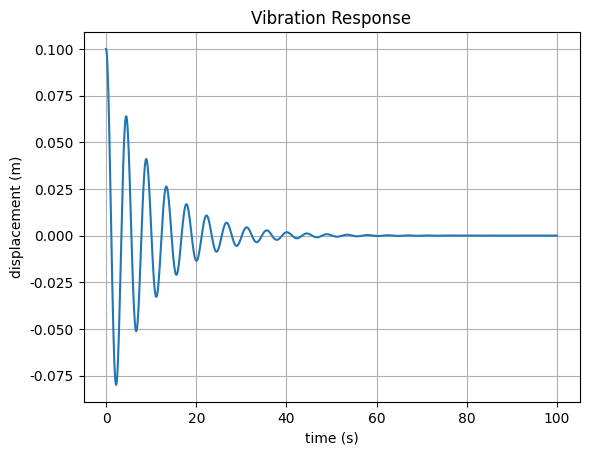

In [5]:
import numpy as np
import matplotlib.pyplot as plt
m=5 #质量
c=1 #阻尼
k=10 #弹性系数
x_0=0.1 #初始位移
v_0=0 #初始速度
u_0=0 #初始位移
t=np.linspace(0,100,1000) #时间范围
omega=np.sqrt(k/m) #自然频率
zeta=c/(2*np.sqrt(m*k)) #阻尼比
omega_d=omega*np.sqrt(1-zeta**2) #阻尼频率
u=np.exp(-zeta*omega*t)*(x_0*np.cos(omega_d*t)+((v_0+zeta*omega*x_0)/omega_d)*np.sin(omega_d*t)) #位移响应
plt.rcParams['font.sans-serif']=['DejaVu Sans'] #设置字体
plt.plot(t,u)
plt.title('Vibration Response')
plt.xlabel('time (s)')
plt.ylabel('displacement (m)')
plt.grid()
plt.show()

homework 1.2

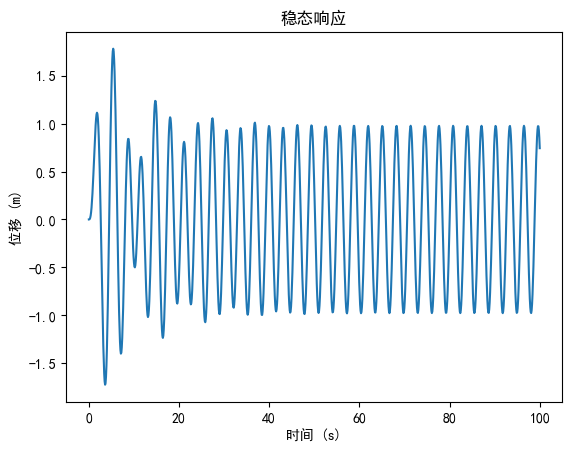

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
m=5 #质量
c=1 #阻尼
k=10 #弹性系数
t=np.linspace(0,100,1000) #时间范围
f=10*np.sin(2*t) #外部激励
A=np.array([[0,1],[-k/m,-c/m]]) #A矩阵
B=np.array([[0],[1/m]]) #B矩阵
C=np.array([[1,0]]) #C矩阵
D=np.array([[0]]) #D矩阵
sys=signal.StateSpace(A,B,C,D) #状态空间模型
t,y,x=signal.lsim(sys,f,t) #求解系统响应
fig,ax=plt.subplots()
plt.rcParams['font.sans-serif']=['SimHei'] #设置中文字体
plt.rcParams['axes.unicode_minus']=False #设置负号显示
ax.set_title('稳态响应')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('位移 (m)')
ax.plot(t,y)
plt.show()

homework 2.1

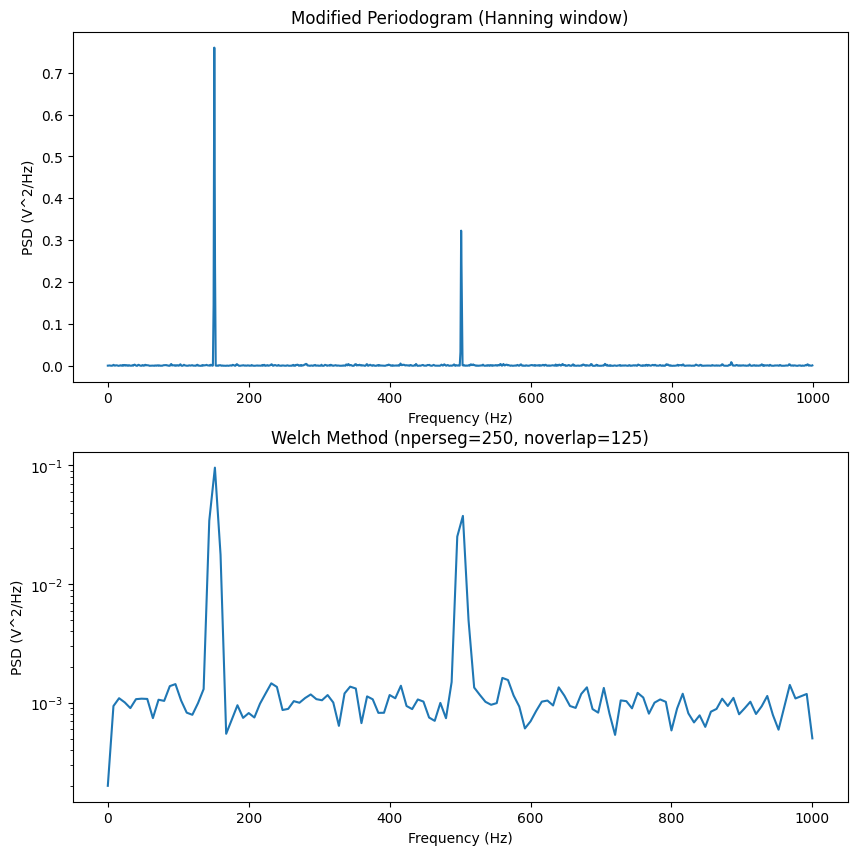

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

N=2000 #采样点数
T=1 #采样时长
fs=N/T #采样频率
df=fs/N #频率分辨率
t=np.linspace(0,T,N) #采样时间点
x=1.5*np.sin(2*np.pi*151*t)+np.sin(2*np.pi*501*t)+np.random.randn(N) #采样信号

window=np.hanning(N) #汉宁窗
sf2=N/np.sum(window**2) #窗能量修正因子
x_windowed=x*window #加窗
y=np.fft.fft(x_windowed/N) #FFT变换
P=abs(y)**2/df*2*sf2 #功率谱密度
f=np.fft.fftfreq(N,d=1/fs) #双边频率
idx=f>=0 #转换为单边谱
f_idx=f[idx]
P_idx=P[idx]

nperseg=N//8 #窗口长度
noverlap=N//16 #重叠长度
f_welch,P_welch=signal.welch(x,fs=fs,window='hann',nperseg=nperseg,noverlap=noverlap,return_onesided=True) #welch法

fig,ax=plt.subplots(2,1,figsize=(10,10))

plt.rcParams['font.sans-serif']=['DejaVu Sans'] #设置字体
plt.rcParams['axes.unicode_minus']=False #设置负号显示
ax[0].set_title('Modified Periodogram (Hanning window)')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('PSD (V^2/Hz)')
ax[0].plot(f_idx,P_idx)

ax[1].set_title(f'Welch Method (nperseg={nperseg}, noverlap={noverlap})')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('PSD (V^2/Hz)')
ax[1].semilogy(f_welch,P_welch)